In [1]:
from models.exc_based_model import ExcitatoryModel
from pathlib import Path
import joblib
from insilico_stimuli.stimuli import GaborSet, CenterSurround
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


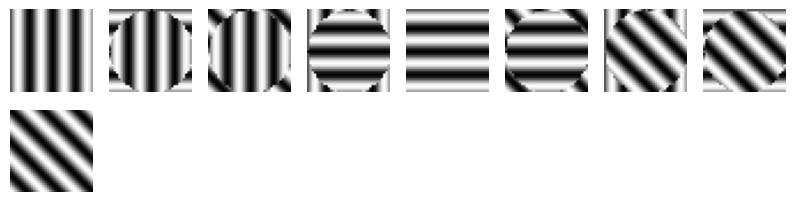

In [2]:
canvas_size                = [36, 36]
locations                  = [[18, 18]]  # center position
sizes_total                = [36]          # total size (center + surround)
sizes_center               = [0.5]           # portion of radius used for center circle
sizes_surround             = [0.5]      # defines the starting portion of radius for surround
contrasts_center           = [1.0]     # try 2 center contrasts
contrasts_surround         = [1.0]          # surround contrast
orientations_center        = [0.0, np.pi/2, np.pi/4]  # variable orientation
orientations_surround      = [0.0, np.pi/2, np.pi/4]  # center only
spatial_frequencies_center = [0.1]           # fixed spatial frequency
phases_center              = [np.pi]  # center phases 
grey_levels                = [0.0]           # fixed grey level
# spatial_frequencies_surround = [0.1, 0.3]  # optional parameter, default: same as spatial_frequencies_center
# phases_surround = [np.pi/4]                # optional parameter, default: same as phases_center

center_surround = CenterSurround(canvas_size=canvas_size, 
        locations=locations,
        sizes_total=sizes_total,
        sizes_center=sizes_center,
        sizes_surround=sizes_surround,
        contrasts_center=contrasts_center,
        contrasts_surround=contrasts_surround,
        orientations_center=orientations_center,
        orientations_surround=orientations_surround,
        spatial_frequencies_center=spatial_frequencies_center,
        phases_center=phases_center,
        grey_levels=grey_levels
)

# plot the generated images
plt.figure(figsize=(10, 5))
for i, img in enumerate(center_surround.images()):
    plt.subplot(4, 8, i + 1)
    plt.imshow(img, cmap='gray', vmin=-1, vmax=1)
    plt.axis('off')

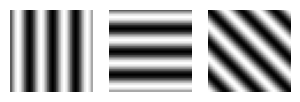

In [3]:
gratings = np.array([center_surround.images()[idx] for idx in range(len(center_surround.images())) if center_surround.params_dict_from_idx(idx)['orientation_center'] == center_surround.params_dict_from_idx(idx)['orientation_surround']])
plt.figure(figsize=(10, 5))
for i, img in enumerate(gratings):
    plt.subplot(4, 8, i + 1)
    plt.imshow(img, cmap='gray', vmin=-1, vmax=1)
    plt.axis('off')

In [4]:
gratings.shape

(3, 36, 36)

In [5]:
data_basepath = Path("/src/project/data/ica/repeat_9_crop_12_comp_40")
x_sigma = 1
I_sigma = 1

print("Loading X_I_models")
X_I_models_path = data_basepath / "layer2_models"
X_I_models = []
for entry in X_I_models_path.iterdir():
    # go through files and load joblib files
    if entry.is_file() and entry.suffix == ".joblib":
        model = joblib.load(entry)
        X_I_models.append(model)

print("Creating hierarchical model")
model = ExcitatoryModel(
    excitatory_stimuli=gratings,
    G_prob=0.5,
    X_sigma=x_sigma,
    X_I_models=X_I_models,
    I_sigma=I_sigma,
)

Loading X_I_models
Creating hierarchical model


In [6]:
prior_samples = model.sample_prior_predictive(n_samples=100, random_seed=42)

Sampling: [G, I, X]


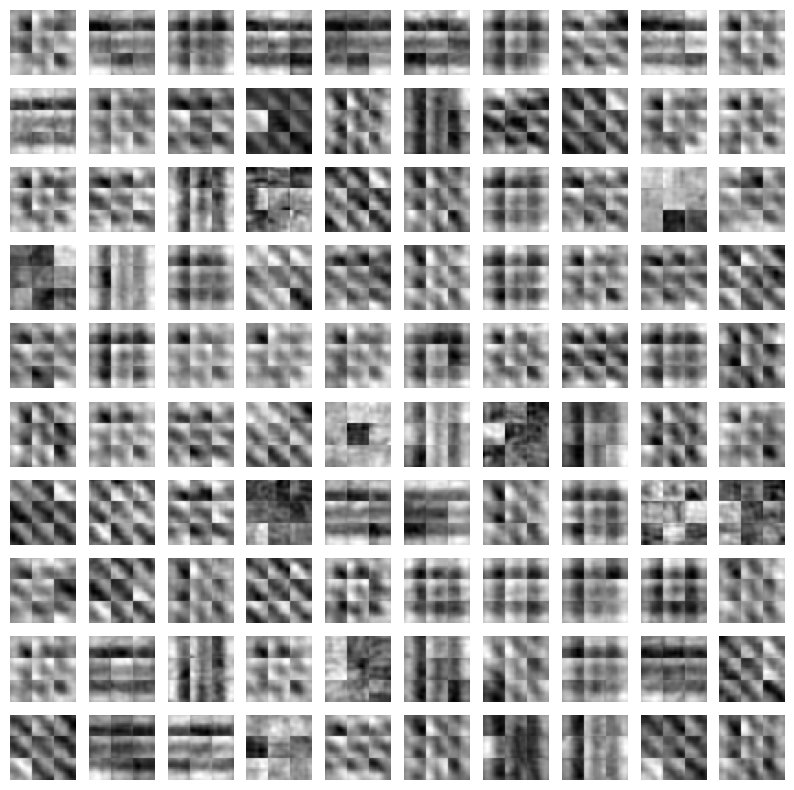

In [7]:
fig, axs = plt.subplots(10, 10, figsize=(10, 10))
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(prior_samples["I"][idx], cmap="gray")
    ax.axis("off")

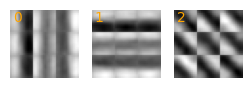

In [8]:
model.visualize_learned_G(nrows=1, ncols=3)

In [9]:
x_samples = prior_samples["X"]
x_correlation = np.corrcoef(x_samples.T)
x_correlation.shape

(360, 360)

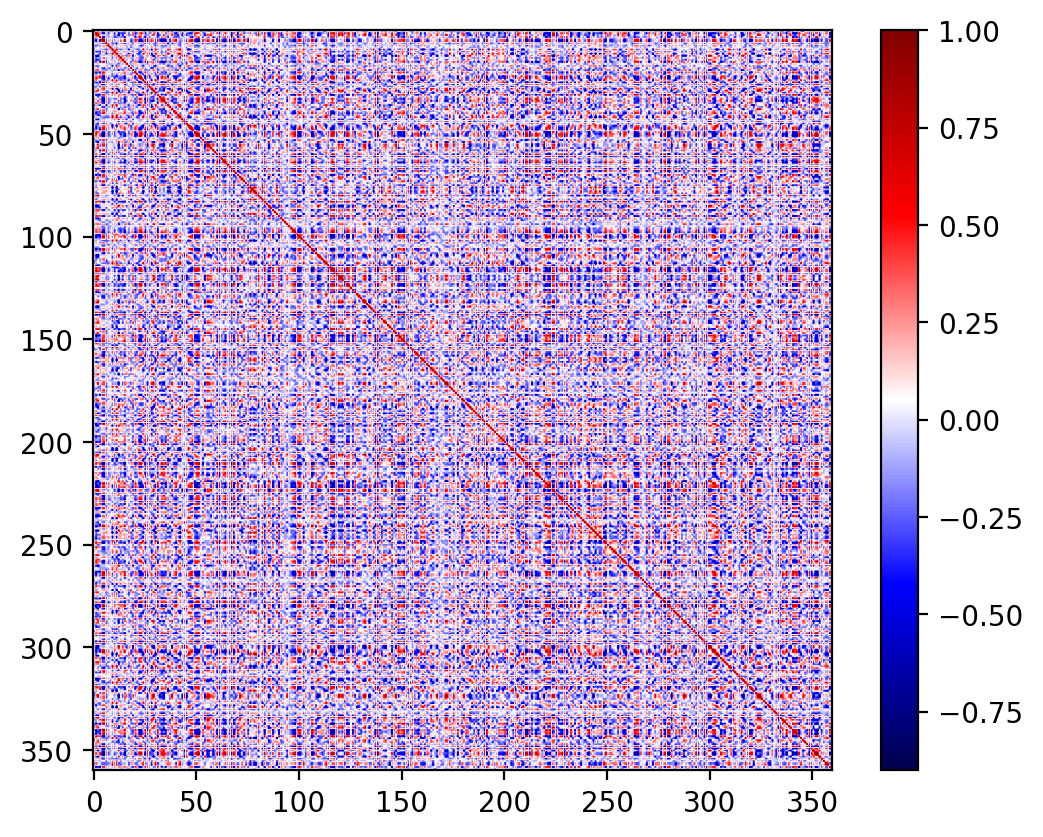

In [10]:
fig, ax = plt.subplots(dpi=200)
im = ax.imshow(x_correlation, cmap="seismic")
fig.colorbar(im, ax=ax)

<Axes: ylabel='Count'>

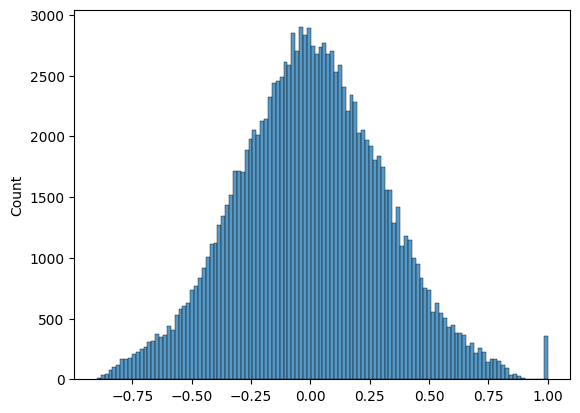

In [11]:
fig, ax = plt.subplots(dpi=100)
sns.histplot(x_correlation.flatten())

In [12]:
# Flatten the upper triangle of the correlation matrix (excluding the diagonal)
upper_triangle = np.triu(x_correlation, k=1).flatten()

# Get the indices of the top 10 correlations
top_10_indices = np.argpartition(upper_triangle, -10)[-10:]

# Convert flat indices to 2D indices
row_indices, col_indices = np.unravel_index(top_10_indices, x_correlation.shape)

# Display the top 10 correlations and their corresponding indices
top_10_correlations = upper_triangle[top_10_indices]
for i, (row, col, correlation) in enumerate(zip(row_indices, col_indices, top_10_correlations), 1):
    print(f"Top {i}: Correlation between elements {row} and {col} is {correlation}")

Top 1: Correlation between elements 42 and 113 is 0.8837953287800672
Top 2: Correlation between elements 191 and 337 is 0.884076200218384
Top 3: Correlation between elements 243 and 260 is 0.8844962170895808
Top 4: Correlation between elements 191 and 302 is 0.8840788332110666
Top 5: Correlation between elements 113 and 248 is 0.8858581634540071
Top 6: Correlation between elements 12 and 260 is 0.8994223390066862
Top 7: Correlation between elements 191 and 340 is 0.8907183816361205
Top 8: Correlation between elements 280 and 340 is 0.8861644109209065
Top 9: Correlation between elements 5 and 191 is 0.9010680789702545
Top 10: Correlation between elements 191 and 280 is 0.9041235586988511


In [13]:
all_X_RFs_flat = np.array([model.mixing_ for model in X_I_models]).transpose(1, 0, 2).reshape(144, -1)
print(all_X_RFs_flat.shape)

(144, 360)


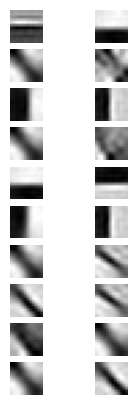

In [14]:
fig, axs = plt.subplots(nrows=10, ncols=2, figsize=(2, 5))
for idx, (row, col, correlation) in enumerate(zip(row_indices, col_indices, top_10_correlations)):
    axs[idx][0].imshow(all_X_RFs_flat[:, row].reshape(12, 12), cmap="gray")
    axs[idx][1].imshow(all_X_RFs_flat[:, col].reshape(12, 12), cmap="gray")
    axs[idx][0].axis("off")
    axs[idx][1].axis("off")

In [15]:
bottom_10_indices = np.argpartition(upper_triangle, 10)[:10]

# Convert flat indices to 2D indices
row_indices, col_indices = np.unravel_index(bottom_10_indices, x_correlation.shape)

# Display the bottom 10 correlations and their corresponding indices
bottom_10_correlations = upper_triangle[bottom_10_indices]
for i, (row, col, correlation) in enumerate(zip(row_indices, col_indices, bottom_10_correlations), 1):
    print(f"Bottom {i}: Correlation between elements {row} and {col} is {correlation}")

Bottom 1: Correlation between elements 109 and 206 is -0.885744924104046
Bottom 2: Correlation between elements 11 and 329 is -0.8938011781810082
Bottom 3: Correlation between elements 248 and 303 is -0.885621141135863
Bottom 4: Correlation between elements 89 and 248 is -0.8829017558543529
Bottom 5: Correlation between elements 191 and 352 is -0.8987568423014682
Bottom 6: Correlation between elements 85 and 132 is -0.8854017430895895
Bottom 7: Correlation between elements 42 and 76 is -0.882091300002828
Bottom 8: Correlation between elements 113 and 244 is -0.8812436206407831
Bottom 9: Correlation between elements 191 and 210 is -0.8807113777528264
Bottom 10: Correlation between elements 42 and 89 is -0.8796618875418808


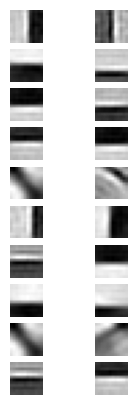

In [16]:
fig, axs = plt.subplots(nrows=10, ncols=2, figsize=(2, 5))
for idx, (row, col, correlation) in enumerate(zip(row_indices, col_indices, bottom_10_correlations)):
    axs[idx][0].imshow(all_X_RFs_flat[:, row].reshape(12, 12), cmap="gray")
    axs[idx][1].imshow(all_X_RFs_flat[:, col].reshape(12, 12), cmap="gray")
    axs[idx][0].axis("off")
    axs[idx][1].axis("off")


In [17]:
threshold = 0.01  # Adjust this threshold based on your definition of "near zero"

# Find indices with correlations near zero
near_zero_indices = np.where(np.abs(x_correlation) < threshold)

# Display the indices and corresponding correlations
for row, col in zip(near_zero_indices[0], near_zero_indices[1]):
    correlation = x_correlation[row, col]
    print(f"Near zero correlation: Elements {row} and {col} with correlation {correlation}")

Near zero correlation: Elements 0 and 14 with correlation -0.009728984366335052
Near zero correlation: Elements 0 and 23 with correlation 0.0010780838179774244
Near zero correlation: Elements 0 and 47 with correlation -0.0085704479885794
Near zero correlation: Elements 0 and 75 with correlation -0.0027106743606814007
Near zero correlation: Elements 0 and 98 with correlation -0.005318514019445364
Near zero correlation: Elements 0 and 104 with correlation 0.005379439681779403
Near zero correlation: Elements 0 and 162 with correlation 0.007104779520460833
Near zero correlation: Elements 0 and 270 with correlation 0.005680442302791656
Near zero correlation: Elements 0 and 278 with correlation 0.00814327632413146
Near zero correlation: Elements 0 and 279 with correlation -0.004475142188222289
Near zero correlation: Elements 0 and 312 with correlation -0.004578330833767468
Near zero correlation: Elements 0 and 313 with correlation -0.00012449466499480665
Near zero correlation: Elements 1 and

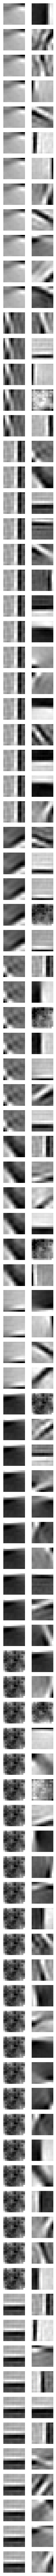

In [18]:
fig, axs = plt.subplots(nrows=100, ncols=2, figsize=(2, 100))
for idx, (row, col, correlation) in enumerate(zip(near_zero_indices[0], near_zero_indices[1], x_correlation[near_zero_indices])):
    if idx >= 100:
        break
    axs[idx][0].imshow(all_X_RFs_flat[:, row].reshape(12, 12), cmap="gray")
    axs[idx][1].imshow(all_X_RFs_flat[:, col].reshape(12, 12), cmap="gray")
    axs[idx][0].axis("off")
    axs[idx][1].axis("off")

In [19]:
all_X_RFs_flat.shape

(144, 360)

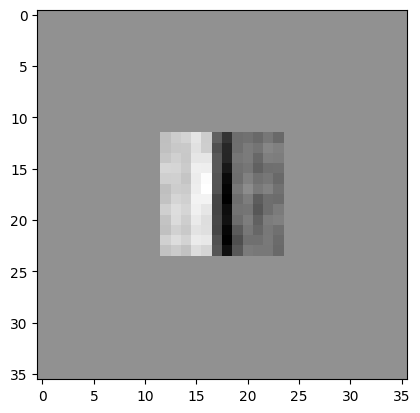

In [20]:
MEI_183 = np.zeros((36, 36))
MEI_183[12:24,12:24] = all_X_RFs_flat[:, 167].reshape(
    (12, 12)
)
plt.imshow(MEI_183, cmap="gray")

In [21]:
post_samples = model.sample_posterior(
    image=MEI_183,
    n_samples=100,
    random_seed=42,
    tune=100,
    chains=4,
    cores=4
)

Only 100 samples in chain.


reshaped_image (1296,)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 100 tune and 100 draw iterations (400 + 400 draws total) took 212 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [22]:
mei_samples = post_samples

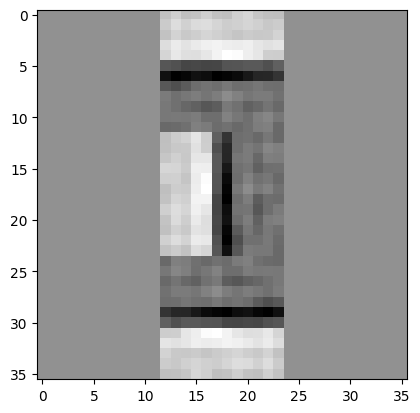

In [23]:
inhibitory_183 = np.zeros((36, 36))
MEI = all_X_RFs_flat[:, 167].reshape(
    (12, 12)
)
inhibitory_183[12:24,12:24] = MEI
inhibitory_183[0:12, 12:24] = np.rot90(MEI, 3)
inhibitory_183[24:36, 12:24] = np.rot90(MEI, 1)
plt.imshow(inhibitory_183, cmap="gray")

In [24]:
inh_samples = model.sample_posterior(
    image=inhibitory_183,
    n_samples=100,
    random_seed=42,
    tune=100,
    chains=4,
    cores=4
)

Only 100 samples in chain.


reshaped_image (1296,)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 100 tune and 100 draw iterations (400 + 400 draws total) took 232 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


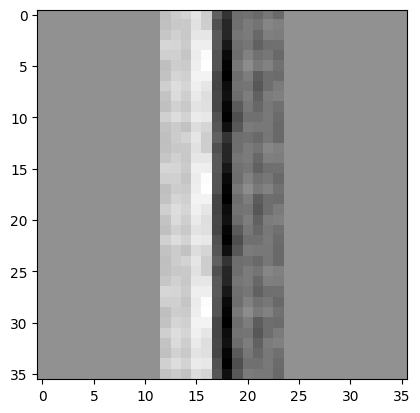

In [25]:
exc_183 = np.zeros((36, 36))
MEI = all_X_RFs_flat[:, 167].reshape(
    (12, 12)
)
exc_183[12:24,12:24] = MEI
exc_183[0:12, 12:24] = MEI
exc_183[24:36, 12:24] = MEI
plt.imshow(exc_183, cmap="gray")

In [26]:
exc_samples = model.sample_posterior(
    image=exc_183,
    n_samples=100,
    random_seed=42,
    tune=100,
    chains=4,
    cores=4
)

Only 100 samples in chain.


reshaped_image (1296,)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 100 tune and 100 draw iterations (400 + 400 draws total) took 220 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [27]:
mei_samples["posterior"]["X"].data.shape

(4, 100, 360)

In [28]:
mei_samples_plot = mei_samples["posterior"]["X"].data.reshape(400, 360)
inh_samples_plot = inh_samples["posterior"]["X"].data.reshape(400, 360)
exc_samples_plot = exc_samples["posterior"]["X"].data.reshape(400, 360)

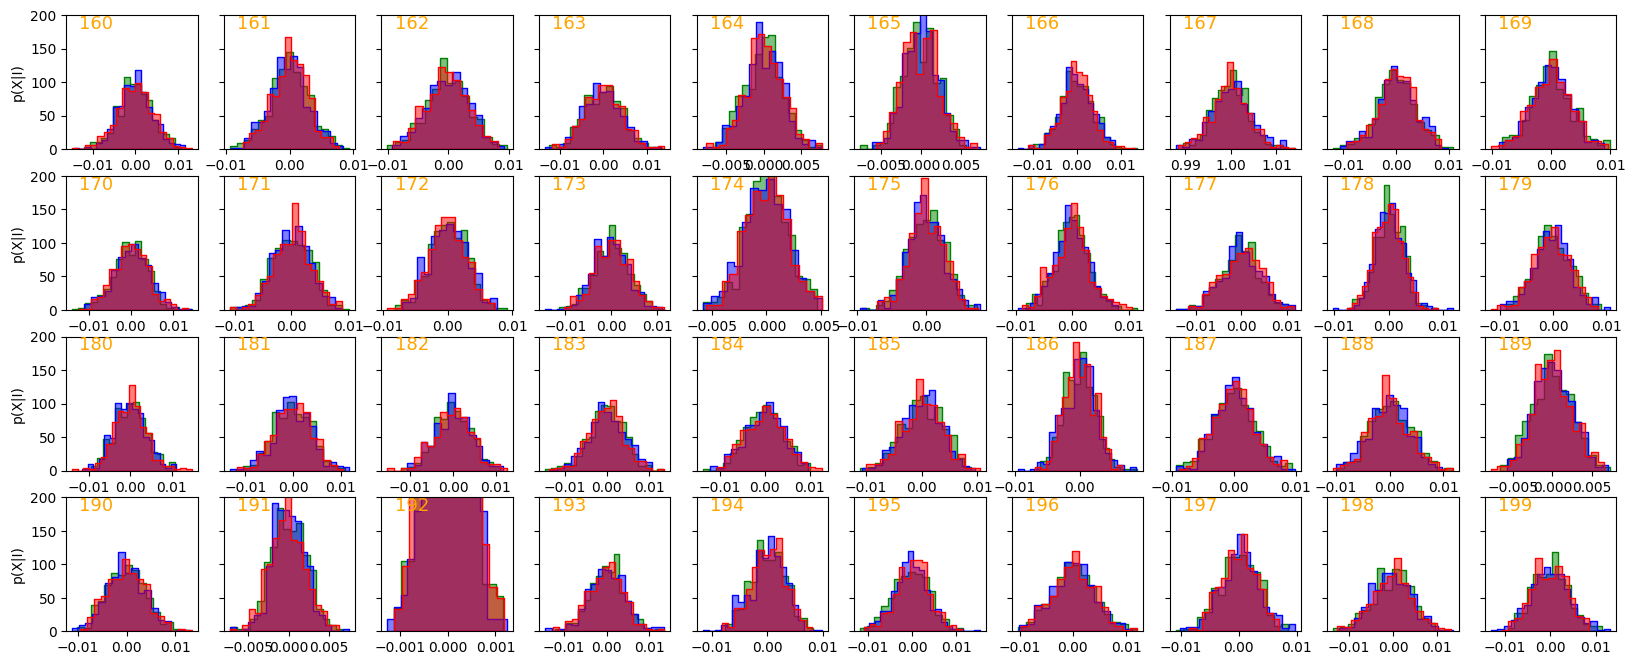

In [29]:
center_offset = 160
fig, axs = plt.subplots(nrows=4, ncols=10, figsize=(2*10, 2*4), sharey=True)
for i, ax in enumerate(axs.flat):
    neuron_id = i + center_offset
    sns.histplot(
        mei_samples_plot[:, neuron_id],
        ax=ax,
        stat="density",
        color="green",
        element="step",
        alpha=0.5,
        label="MEI"
    )
    sns.histplot(
        inh_samples_plot[:, neuron_id],
        ax=ax,
        stat="density",
        color="blue",
        element="step",
        alpha=0.5,
        label="Disrupting"
    )
    sns.histplot(
        exc_samples_plot[:, neuron_id],
        ax=ax,
        stat="density",
        color="red",
        element="step",
        alpha=0.5,
        label="Completing"
    )
    # samples_mean = samples.mean(axis=0)
    # ax.axvline(samples_mean[neuron_id], color="red", linestyle="--")
    # ax.text(0.8, 0.9, f"{samples_mean[neuron_id]*1000:.1f}e-3", size=10, ha="center", va="center", transform=ax.transAxes, color='red')
    ax.text(
        0.1,
        0.9,
        str(neuron_id),
        color="orange",
        fontsize=13,
        transform=ax.transAxes,
    )
    ax.set_ylim([0, 200])
    ax.set_ylabel("p(X|I)")


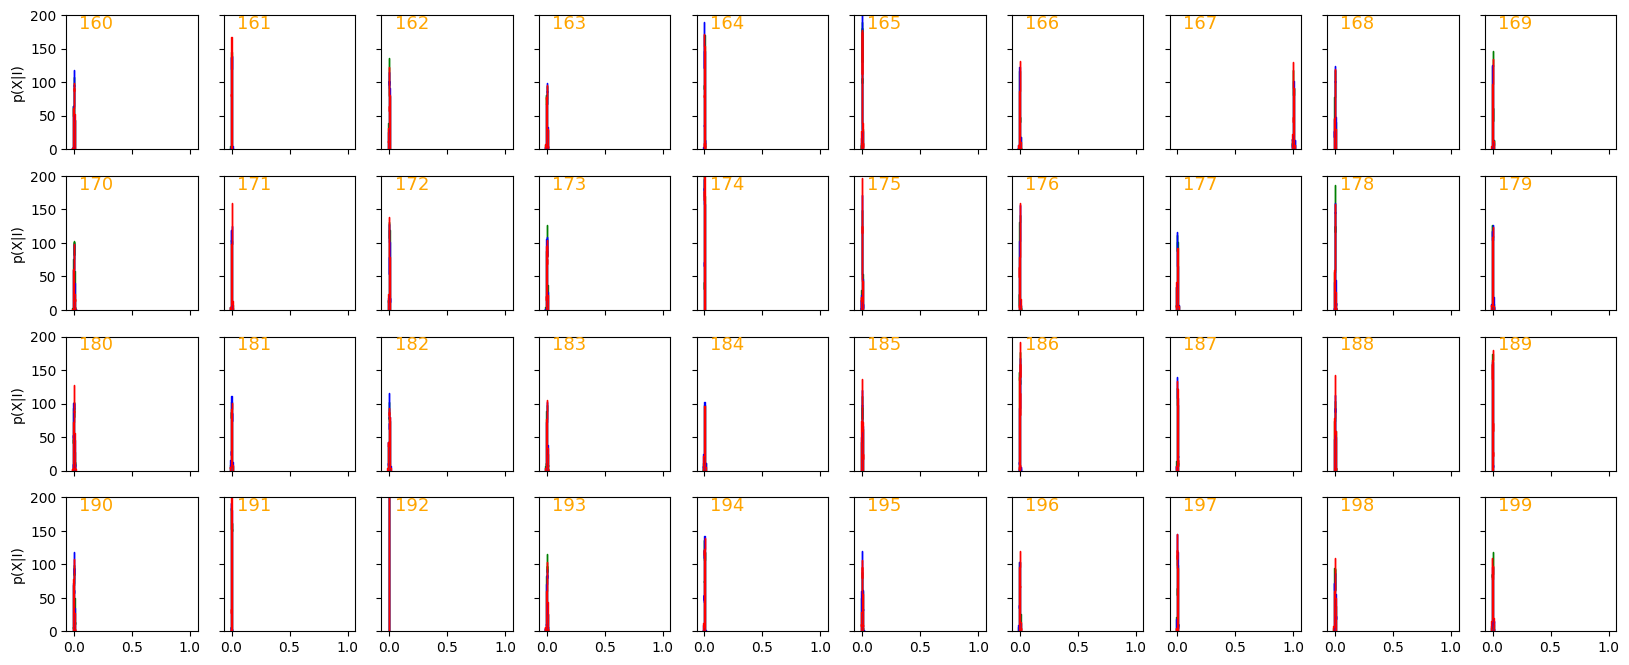

In [30]:
center_offset = 160
fig, axs = plt.subplots(nrows=4, ncols=10, figsize=(2*10, 2*4), sharey=True, sharex=True)
for i, ax in enumerate(axs.flat):
    neuron_id = i + center_offset
    sns.histplot(
        mei_samples_plot[:, neuron_id],
        ax=ax,
        stat="density",
        color="green",
        element="step",
        alpha=0.5,
        label="MEI"
    )
    sns.histplot(
        inh_samples_plot[:, neuron_id],
        ax=ax,
        stat="density",
        color="blue",
        element="step",
        alpha=0.5,
        label="Disrupting"
    )
    sns.histplot(
        exc_samples_plot[:, neuron_id],
        ax=ax,
        stat="density",
        color="red",
        element="step",
        alpha=0.5,
        label="Completing"
    )
    # samples_mean = samples.mean(axis=0)
    # ax.axvline(samples_mean[neuron_id], color="red", linestyle="--")
    # ax.text(0.8, 0.9, f"{samples_mean[neuron_id]*1000:.1f}e-3", size=10, ha="center", va="center", transform=ax.transAxes, color='red')
    ax.text(
        0.1,
        0.9,
        str(neuron_id),
        color="orange",
        fontsize=13,
        transform=ax.transAxes,
    )
    ax.set_ylim([0, 200])
    ax.set_ylabel("p(X|I)")


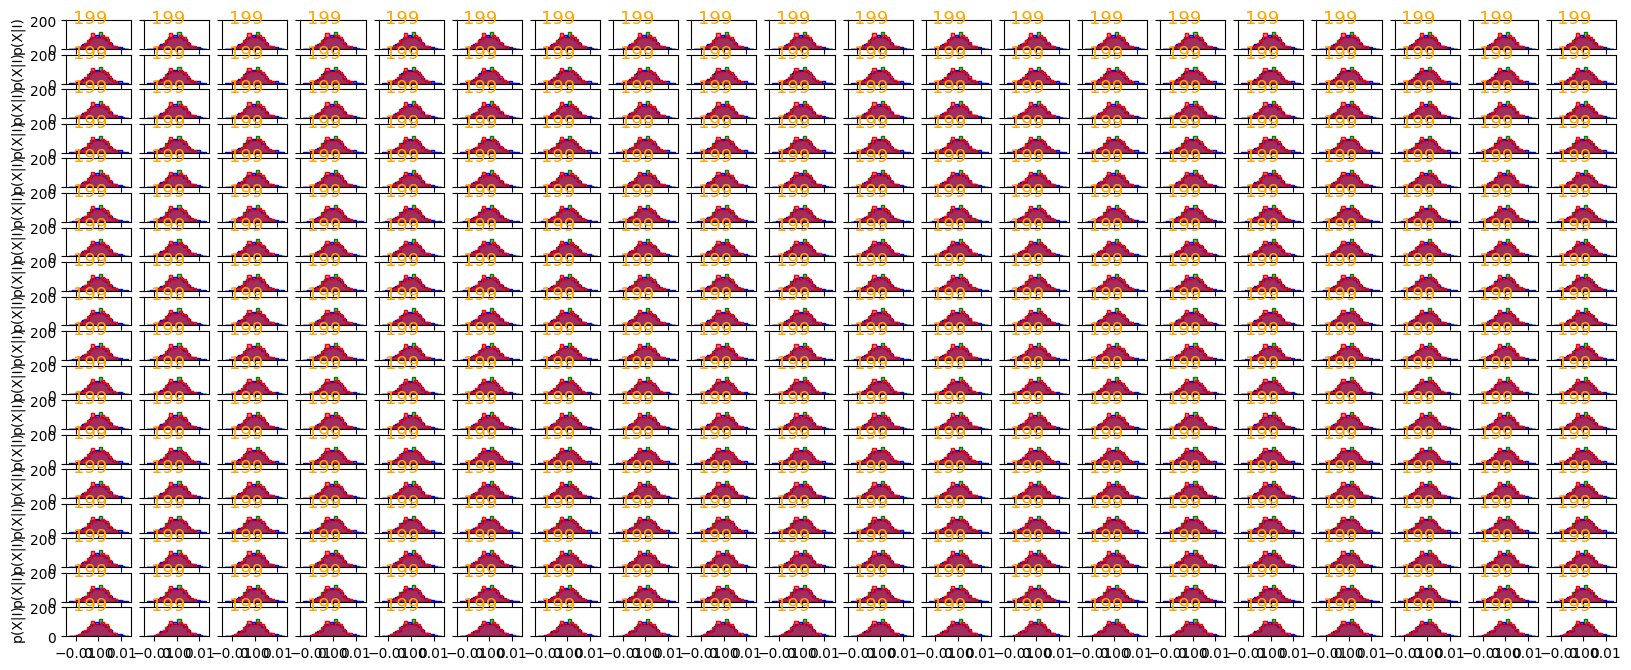

In [31]:
# center_offset = 160
fig, axs = plt.subplots(nrows=18, ncols=20, figsize=(2*10, 2*4), sharey=True, sharex=True)
for i, ax in enumerate(axs.flat):
    # neuron_id = i + center_offset
    sns.histplot(
        mei_samples_plot[:, neuron_id],
        ax=ax,
        stat="density",
        color="green",
        element="step",
        alpha=0.5,
        label="MEI"
    )
    sns.histplot(
        inh_samples_plot[:, neuron_id],
        ax=ax,
        stat="density",
        color="blue",
        element="step",
        alpha=0.5,
        label="Disrupting"
    )
    sns.histplot(
        exc_samples_plot[:, neuron_id],
        ax=ax,
        stat="density",
        color="red",
        element="step",
        alpha=0.5,
        label="Completing"
    )
    # samples_mean = samples.mean(axis=0)
    # ax.axvline(samples_mean[neuron_id], color="red", linestyle="--")
    # ax.text(0.8, 0.9, f"{samples_mean[neuron_id]*1000:.1f}e-3", size=10, ha="center", va="center", transform=ax.transAxes, color='red')
    ax.text(
        0.1,
        0.9,
        str(neuron_id),
        color="orange",
        fontsize=13,
        transform=ax.transAxes,
    )
    ax.set_ylim([0, 200])
    ax.set_ylabel("p(X|I)")


In [32]:
exc_samples["posterior"]["G"].data.shape

(4, 100, 3)

In [33]:
exc_G_samples = exc_samples["posterior"]["G"].data.reshape(400, 3)
inh_G_samples = inh_samples["posterior"]["G"].data.reshape(400, 3)
mei_G_samples = mei_samples["posterior"]["G"].data.reshape(400, 3)

In [34]:
exc_G_samples = exc_G_samples.sum(axis=0)
inh_G_samples = inh_G_samples.sum(axis=0)
mei_G_samples = mei_G_samples.sum(axis=0)

In [35]:
exc_G_samples, inh_G_samples, mei_G_samples

(array([0, 0, 0]), array([0, 0, 0]), array([0, 0, 0]))

In [36]:
ax.bar([0, 1, 2], exc_G_samples)

<BarContainer object of 3 artists>

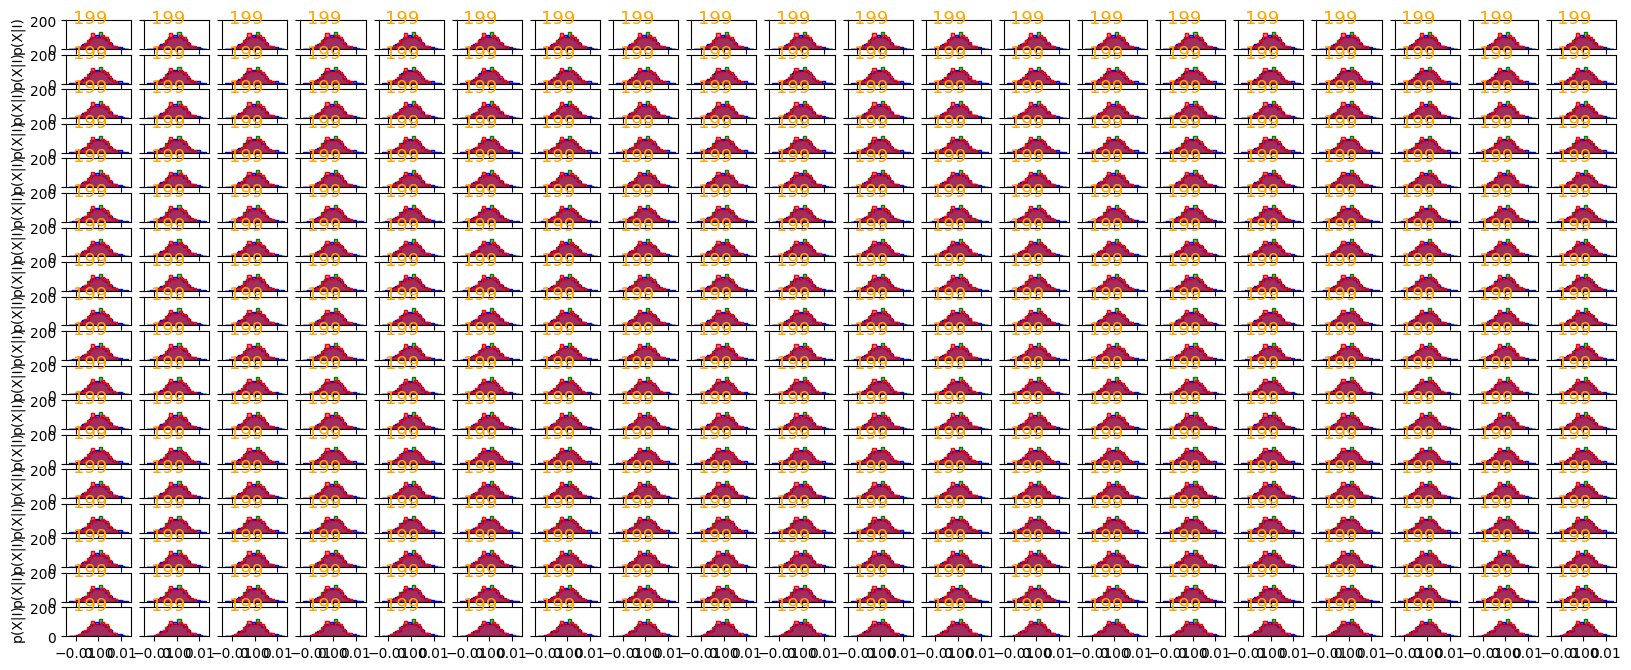

In [37]:
# center_offset = 160
fig, axs = plt.subplots(nrows=18, ncols=20, figsize=(2*10, 2*4), sharey=True, sharex=True)
for i, ax in enumerate(axs.flat):
    # neuron_id = i + center_offset
    sns.histplot(
        mei_samples_plot[:, neuron_id],
        ax=ax,
        stat="density",
        color="green",
        element="step",
        alpha=0.5,
        label="MEI"
    )
    sns.histplot(
        inh_samples_plot[:, neuron_id],
        ax=ax,
        stat="density",
        color="blue",
        element="step",
        alpha=0.5,
        label="Disrupting"
    )
    sns.histplot(
        exc_samples_plot[:, neuron_id],
        ax=ax,
        stat="density",
        color="red",
        element="step",
        alpha=0.5,
        label="Completing"
    )
    # samples_mean = samples.mean(axis=0)
    # ax.axvline(samples_mean[neuron_id], color="red", linestyle="--")
    # ax.text(0.8, 0.9, f"{samples_mean[neuron_id]*1000:.1f}e-3", size=10, ha="center", va="center", transform=ax.transAxes, color='red')
    ax.text(
        0.1,
        0.9,
        str(neuron_id),
        color="orange",
        fontsize=13,
        transform=ax.transAxes,
    )
    ax.set_ylim([0, 200])
    ax.set_ylabel("p(X|I)")


In [38]:
post_samples = model.sample_posterior(
    image=gratings[0],
    n_samples=100,
    random_seed=42,
    tune=1000,
    chains=4,
    cores=4
)

Only 100 samples in chain.


reshaped_image (1296,)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 1_000 tune and 100 draw iterations (4_000 + 400 draws total) took 261 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [39]:
post_samples["posterior"]["X"].data.shape

(4, 100, 360)

In [40]:
samples = post_samples["posterior"]["X"].data.reshape(400, 360)


In [41]:
np.save("exc_model_samples.npy", samples)

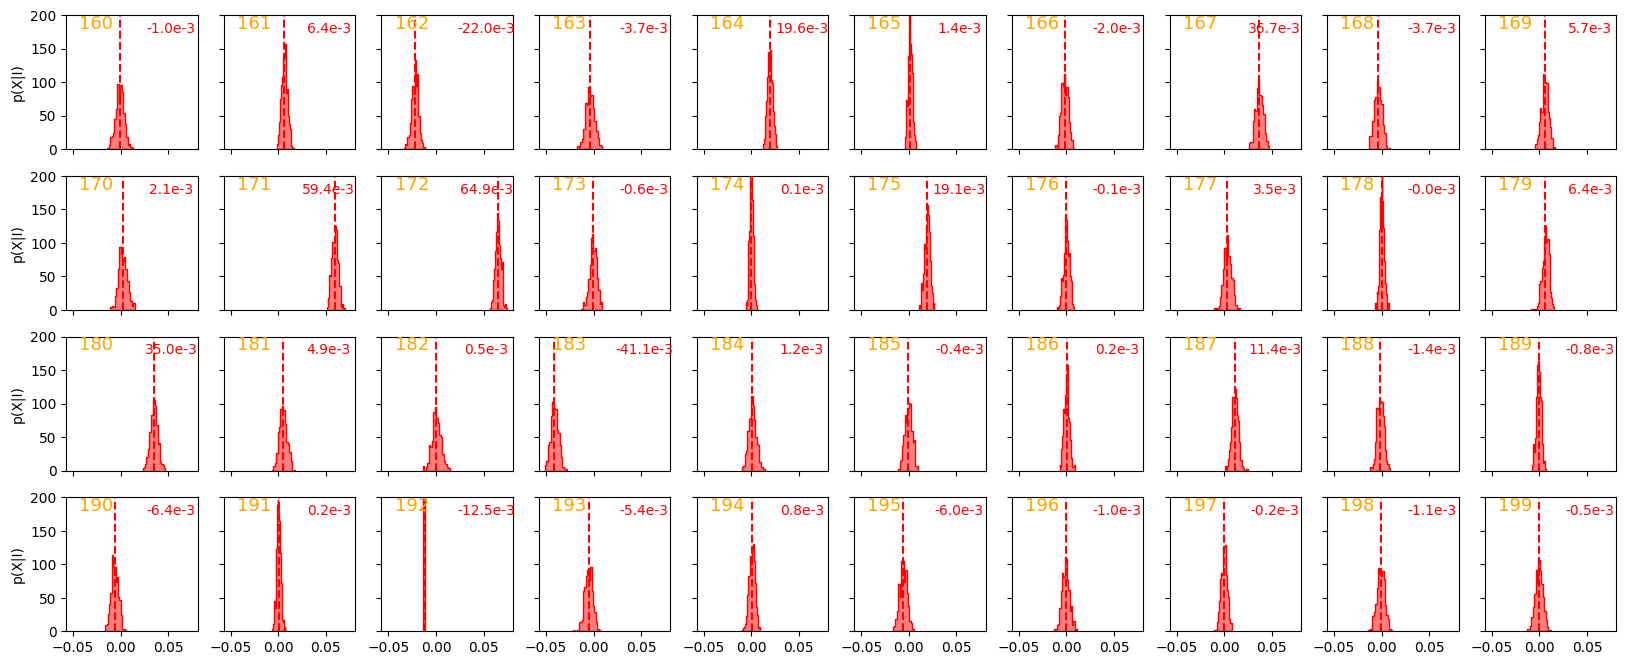

In [42]:
center_offset = 160
fig, axs = plt.subplots(nrows=4, ncols=10, figsize=(2*10, 2*4), sharex=True, sharey=True)
for i, ax in enumerate(axs.flat):
    neuron_id = i + center_offset
    sns.histplot(
        samples[:, neuron_id],
        ax=ax,
        stat="density",
        color="red",
        element="step",
        alpha=0.5,
    )
    samples_mean = samples.mean(axis=0)
    ax.axvline(samples_mean[neuron_id], color="red", linestyle="--")
    ax.text(0.8, 0.9, f"{samples_mean[neuron_id]*1000:.1f}e-3", size=10, ha="center", va="center", transform=ax.transAxes, color='red')
    ax.text(
        0.1,
        0.9,
        str(neuron_id),
        color="orange",
        fontsize=13,
        transform=ax.transAxes,
    )
    ax.set_ylim([0, 200])
    ax.set_ylabel("p(X|I)")

In [43]:
all_X_RFs_flat.shape

(144, 360)

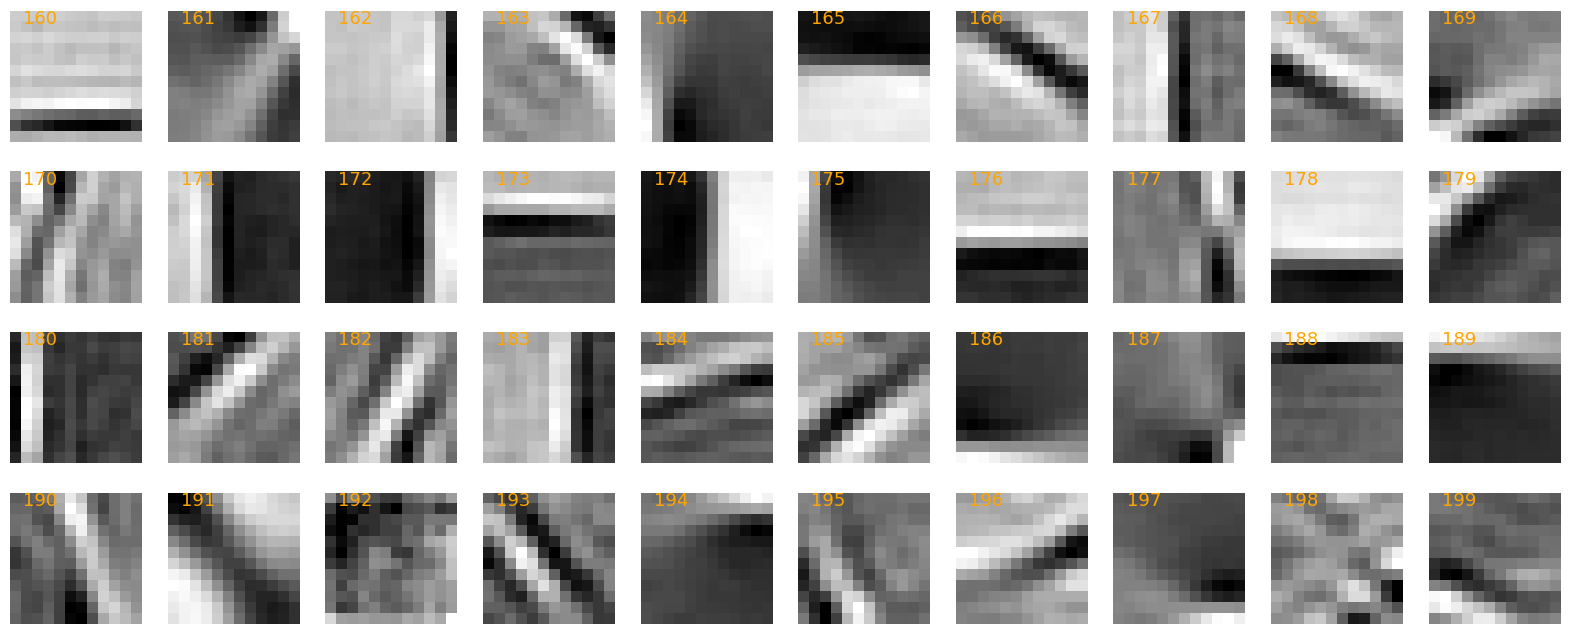

In [44]:
fig, axs = plt.subplots(nrows=4, ncols=10, figsize=(2*10, 2*4))
for i, ax in enumerate(axs.flat):
    neuron_id = i + center_offset
    ax.imshow(all_X_RFs_flat[:, neuron_id].reshape(12, 12), cmap="gray")
    ax.text(
        0.1,
        0.9,
        str(neuron_id),
        color="orange",
        fontsize=13,
        transform=ax.transAxes,
    )
    ax.axis("off")

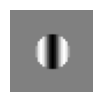

In [45]:
canvas_size                = [36, 36]
locations                  = [[18, 18]]  # center position
sizes_total                = [15]          # total size (center + surround)
sizes_center               = [0.5]           # portion of radius used for center circle
sizes_surround             = [0.5]      # defines the starting portion of radius for surround
contrasts_center           = [1.0]     # try 2 center contrasts
contrasts_surround         = [0]          # surround contrast
orientations_center        = [0.0]  # variable orientation
orientations_surround      = [0.0]  # center only
spatial_frequencies_center = [0.1]           # fixed spatial frequency
phases_center              = [np.pi]  # center phases 
grey_levels                = [0.0]           # fixed grey level
# spatial_frequencies_surround = [0.1, 0.3]  # optional parameter, default: same as spatial_frequencies_center
# phases_surround = [np.pi/4]                # optional parameter, default: same as phases_center

center_surround = CenterSurround(canvas_size=canvas_size, 
        locations=locations,
        sizes_total=sizes_total,
        sizes_center=sizes_center,
        sizes_surround=sizes_surround,
        contrasts_center=contrasts_center,
        contrasts_surround=contrasts_surround,
        orientations_center=orientations_center,
        orientations_surround=orientations_surround,
        spatial_frequencies_center=spatial_frequencies_center,
        phases_center=phases_center,
        grey_levels=grey_levels
)

# plot the generated images
plt.figure(figsize=(10, 5))
for i, img in enumerate(center_surround.images()):
    plt.subplot(4, 8, i + 1)
    plt.imshow(img, cmap='gray', vmin=-1, vmax=1)
    plt.axis('off')